In [1]:
import pandas as pd
import numpy as np
import math
from math import floor
import scipy
import matplotlib.pyplot as plt
import sklearn 
import xarray as xr
from sklearn.tree import DecisionTreeRegressor
import matplotlib.patches as mpl_patches
import torch

from sklearn.model_selection import train_test_split , LeaveOneOut, cross_val_score
cv=LeaveOneOut()
# Import StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() #utilisé pour supprimer la moyenne et mettre les caractéristiques 
#à l'échelle de la variance unitaire. Cela permet d'éviter que certaines caractéristiques ne 
# dominent le modèle en raison de différences d'échelle.
# Import LinearRegression.
from sklearn.linear_model import LinearRegression
# Import metrics.
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, root_mean_squared_error, mean_absolute_error

import os

os.chdir('C:/Users/leoge/OneDrive/Documents/Centrale Nantes/ei4/R&D')

In [2]:
import transformers
# import datasets 
# import evaluate 
# import accelerate 
# import gluonts 
import ujson
from torch import nn
from torch.utils.data import Dataset, DataLoader



# SETUP

## setup definition

In [3]:
# time span
time_range_min=-12000 #a cal. years BP
time_range_max=0   #in cal. years BP 0 = 1950 AD (Anno Domini: "après JC")
# spatial span ; span used in the paper
lat_min,lat_max=45,55 # degree north
lon_min,lon_max=90,100 # degree east

# measurments lakes
lakes=['M14','M15','O6','O14','O15','O16']
lat=[50.0755555556,49.7858333333,49.8213888889,50.0283333333,50.0080555556,50.0186111111]
lon=[-95.4022222222,-95.1902777778,-94.7836111111,-94.8244444444,-94.9825,-94.8508333333]
altitude=[330,337,361,332,339,337]
measurments=pd.DataFrame({'Lake':lakes,'lat':lat,'lon':lon,'altitude':altitude})

lat_meas=measurments.describe().loc['mean'].lat
lon_meas=measurments.describe().loc['mean'].lon
lat_meas,lon_meas #degree north, degree east

time_resolution= 50 #in a cal. years BP
time_array=np.arange(time_range_min,time_range_max+time_resolution,time_resolution ) #in cal. years BP

roll_window=10
size_test=0.25


In [4]:
def rolling_mean_cumsum(a, window=3):
    ret = np.cumsum(a, dtype=float)
    ret[window:] = ret[window:] - ret[:-window]
    return ret[window - 1:] / window

## Load PRECT and TS data

In [5]:

#Precipitation rate #decadal mean annual # averages 22ka-2000AD 
#PRECT = Total precipitation rate: PRECC+PRECL #PRECC = Convective precipitation rate #PRECL = Large-scale (stable) precipitation rate
PRECT = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.PRECT.nc')
PRECT = PRECT.sel(lat=lat_meas,lon=360+lon_meas,method='nearest') # select pixel of interest of dataset
PRECT=PRECT.rename({'time':'Age'})
PRECC = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECC':PRECT.PRECC.values})
PRECL = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECL':PRECT.PRECL.values})
PRECT = pd.DataFrame({'Age':PRECT.Age.values*1000,'PRECT':PRECT.PRECT.values})

#Temperature Surface
TS = xr.open_dataset(
    './climate_data/TraCE-21K-II.ann.TS.nc')
TS = TS.sel(lat=lat_meas,lon=360+lon_meas,method='nearest') # select pixel of interest
TS=TS.rename({'time':'Age'})
TS = pd.DataFrame({'Age':TS.Age.values*1000,'TS':TS.TS.values})

AnnTemp = pd.read_csv('./25155593/AnnTemp.csv')
AnnTemp=AnnTemp[['Age','AnnTemp']].dropna()
AnnTemp = AnnTemp.reindex(index=AnnTemp.index[::-1]).reset_index(drop=True)
AnnTemp.Age=AnnTemp.Age*(-1)
Human = pd.read_csv('./25155593/Human.csv')
Human = Human.reindex(index = Human.index[::-1]).reset_index(drop=True)
Human.Age = Human.Age /(-1) #conversion to 12000 to 0 

## Load fire data

In [6]:
# Fire frequency
FF = pd.read_csv('./25155593/FFBootCISap.csv')
FF= FF.reindex(index=FF.index[::-1]).reset_index(drop=True)
FF.Age = FF.Age /(-1)
# burning biomass
BB = pd.read_csv('./25155593/BBBootCISap.csv')
BB = BB.reindex(index=BB.index[::-1]).reset_index(drop=True)
BB.Age = BB.Age/(-1)
#FS = FF/BB
FS = pd.read_csv('./25155593/FSBootCISap.csv')
FS = FS.reindex(index=FS.index[::-1]).reset_index(drop=True)
FS.Age = FS.Age/(-1)

FF=FF.rename(columns={'Mean':'FF_Mean'})
FS=FS.rename(columns={'Mean':'FS_Mean'})
BB=BB.rename(columns={'Mean':'BB_Mean'})

## Load environmental data

créer le dataframe Age, TS, PRECT, human et dataframe BB, FF , FS



interpolation sur time array -12000 à 0 years cal. BP avec pas de 50 ans

merge les 2 dataframes en 1 df_annual

In [7]:
list_vars=['TS','PRECT','human'] # ,'PRECC','PRECL'
list_df=[TS,PRECT,Human] # ,PRECC,PRECL

dict={'Age':time_array}
for i in range (len(list_vars)):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_vars[i]].values)
    mean_3_to_5_ka= list_df[i].loc[(list_df[i].Age < -3000) & (list_df[i].Age > -5000)][list_vars[i]].mean()
    f_interp = f_interp - mean_3_to_5_ka
    dict.update({list_vars[i]:f_interp})

list_df=[BB,FF,FS]
list_var= ['BB_Mean','FF_Mean','FS_Mean']
dict2={'Age':time_array}
n=len(list_df)
for i in range (0,n):
    f_interp = np.interp(time_array,list_df[i].Age.values,list_df[i][list_var[i]].values)
    dict2.update({list_var[i]:f_interp})

dict.update(dict2)

df_annual = pd.DataFrame(dict)
df_annual.Age = time_array # convert -12 ka to 12000 cal. years BP

# lissage des données par moyenne glissante sur valeur(roll_window)  pas de temps (moyenne glissante sur 10 pdt. )
df_annual = df_annual.rolling(window=roll_window).mean()


## Load pollen data

creation dataframe des données pollen, interpolation sur time array, lissage par moyenne glissante sur roll_window pas de temps

In [8]:
Pollen50Reg = pd.read_csv('./25155593/Pollen50Reg.csv')
Pollen50Reg
pollen = Pollen50Reg

cols_pollen=Pollen50Reg.columns

Pollen50Reg.Age = Pollen50Reg.Age # turn age into -12 to 0 ka cal. years BP (same as environmental data)
Pollen50Reg = Pollen50Reg.iloc[::-1].reset_index(drop=True)

time_pollen= time_array #np.arange(0,np.max(Pollen50Reg.Age.values),50)
df=Pollen50Reg
df.Age=df.Age*(-1)
cols=df.columns
dict = {'Age':time_pollen}
for x in cols:
    fp=df[x].values
    f_interp=np.interp(x=time_pollen,xp=df.Age,fp=fp)
    dict.update({x:f_interp})

Pollen50Reg=pd.DataFrame(dict)
Pollen50Reg.Age=Pollen50Reg.Age
Pollen50Reg = Pollen50Reg.rolling(window=roll_window).mean()
# pollen_smooth = Pollen50Reg.rolling(window=roll_window).mean()


# type of plants by family
conifers = Pollen50Reg.columns[1:6]
deciduous = Pollen50Reg.columns[6:12]
herbaceous = Pollen50Reg.columns[12:-1]
aquatics =Pollen50Reg.columns[-1:]


## df_data avec linear features

merge df_pollen et df_annual on 'Age'

In [9]:
df_data = pd.merge(Pollen50Reg, df_annual, how='inner', on=['Age', 'Age'])
array_age=df_data.Age

df_data=df_data.dropna()

## df_all avec linear and diff features

#### bi coeff

In [10]:

df_data_diff=df_data.diff(periods=1,axis=0)
df_data_diff.columns=df_data.columns+'_diff'
df_data_diff.Age_diff = array_age
df_data_diff.rename(columns={'Age_diff':'Age'}, inplace=True)

df_all = pd.merge(df_data,df_data_diff,how='inner',on=['Age','Age'])

In [11]:
df_all

,Age,Abies,Cupressaceae,Larix,Picea,Pinus,Alnus,Betula,Populus,Quercus,...,Chenopodium_diff,Cyperaceae_diff,Poaceae_diff,Aquatics_diff,TS_diff,PRECT_diff,human_diff,BB_Mean_diff,FF_Mean_diff,FS_Mean_diff
0,-10075.0,0.741434,1.261133,0.424863,6.968004,29.075520,0.697558,6.617940,0.101637,0.770505,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-10025.0,0.873209,1.407602,0.392984,6.555002,30.888718,0.791408,7.312886,0.092125,0.793890,...,0.117131,-0.010866,0.319898,-0.003848,0.249950,-5.507859e-11,0.016213,0.002481,0.000126,-0.003660
2,-9975.0,1.000735,1.563662,0.366332,6.375046,32.476418,0.876996,7.994360,0.081999,0.826035,...,0.103210,-0.010815,0.343230,-0.002888,0.250980,-5.125490e-11,-0.029918,-0.000019,0.000125,-0.006936
3,-9925.0,1.120999,1.737655,0.348188,6.392211,33.854024,0.951295,8.666453,0.072638,0.870060,...,0.093028,-0.010298,0.364562,-0.000971,0.225827,9.259791e-11,-0.063369,-0.000805,0.000124,-0.007936
4,-9875.0,1.163438,1.825449,0.347023,6.381536,33.684606,0.942603,9.059763,0.066216,0.882082,...,0.006965,-0.008665,0.185392,-0.036937,0.324814,5.325760e-11,-0.092451,-0.007439,0.000122,-0.016523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,-425.0,1.579313,0.618790,1.006781,10.538044,57.340755,5.155906,12.358982,0.378719,1.712703,...,0.013587,-0.010682,-0.018919,-0.005883,-0.089955,4.763802e-11,-1.243483,-0.000779,-0.000045,0.001881
194,-375.0,1.507726,0.674406,1.055653,10.573197,57.172066,5.114903,12.532925,0.382918,1.709806,...,0.000188,-0.018167,0.008055,-0.000787,0.012017,1.859175e-10,-1.281547,-0.001516,-0.000042,0.000738
195,-325.0,1.418270,0.753215,1.100105,10.595657,57.096573,5.006039,12.650923,0.388004,1.692032,...,-0.009891,-0.019414,0.022178,0.005067,0.005765,-1.494682e-11,-1.285093,-0.001524,-0.000039,0.001046
196,-275.0,1.321588,0.831572,1.140763,10.574111,57.079906,4.877701,12.737019,0.392090,1.664064,...,-0.014999,-0.017745,0.023650,0.010922,-0.077092,8.636372e-11,-1.221918,0.001856,-0.000036,0.005558


# Transformers

## function and class

In [12]:

def make_sequences(X, Y, input_len, pred_len):
    seqs = []
    for i in range(len(X) - input_len - pred_len + 1):
        src = X[i : i + input_len]
        tgt = Y[i + input_len : i + input_len + pred_len]
        seqs.append((src, tgt))
    return seqs

class TimeSeriesDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        src, tgt = self.seqs[idx]
        return torch.tensor(src, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)

# --- simple Informer-style encoder + probabilistic output ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class InformerProbModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, pred_len=10):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=input_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, pred_len * 2)  # mean + logvar
        self.pred_len = pred_len

    def forward(self, src):
        x = self.input_proj(src)
        x = self.pos_enc(x)
        memory = self.encoder(x)
        h = memory[:, -1, :]  # use last time step
        out = self.out(h)
        out = out.view(-1, self.pred_len, 2)
        return out

def gaussian_nll(pred, target):
    mean, logvar = pred[..., 0], pred[..., 1]
    var = torch.exp(logvar)
    return 0.5 * (logvar + (target.squeeze(-1) - mean) ** 2 / var).mean()

In [13]:
feature_cols=feats=(df_all.columns[1:22].append(df_all.columns[25:-3]))#.append(df_all.columns[-3:]).values
feats

Index(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus', 'Betula',
       'Populus', 'Quercus', 'Salix', 'Ulmus', 'Ambrosia', 'Artemisia',
       'Asteraceae', 'Chenopodium', 'Cyperaceae', 'Poaceae', 'Aquatics', 'TS',
       'PRECT', 'human', 'Abies_diff', 'Cupressaceae_diff', 'Larix_diff',
       'Picea_diff', 'Pinus_diff', 'Alnus_diff', 'Betula_diff', 'Populus_diff',
       'Quercus_diff', 'Salix_diff', 'Ulmus_diff', 'Ambrosia_diff',
       'Artemisia_diff', 'Asteraceae_diff', 'Chenopodium_diff',
       'Cyperaceae_diff', 'Poaceae_diff', 'Aquatics_diff', 'TS_diff',
       'PRECT_diff', 'human_diff'],
      dtype='object')

## lin and diff

NameError: name 'mean_smooth' is not defined

epoch 01 train_loss=0.88338 val_loss=0.73135
epoch 02 train_loss=0.67039 val_loss=0.57051
epoch 03 train_loss=0.52841 val_loss=0.46789
epoch 04 train_loss=0.44198 val_loss=0.39454
epoch 05 train_loss=0.36311 val_loss=0.33638
epoch 06 train_loss=0.31559 val_loss=0.28592
epoch 07 train_loss=0.27616 val_loss=0.24121
epoch 08 train_loss=0.22979 val_loss=0.19919
epoch 09 train_loss=0.17209 val_loss=0.15994
epoch 10 train_loss=0.13863 val_loss=0.12330
forecast FF_Mean (next steps): [0.00576469 0.00573369 0.00576585 0.00559041 0.00587718 0.00580656
 0.00543487 0.00502204 0.00572145 0.00554941 0.00524448 0.00558849
 0.00572162 0.00598136 0.00571223 0.00574566 0.00560298 0.00582122
 0.00541328 0.00549047 0.00518504 0.00550832 0.00564086 0.00596292
 0.00566722 0.00538329 0.0055403  0.00552916 0.00566141 0.00551895
 0.0052522  0.0055161  0.00509595 0.00574782 0.00549904 0.00571084
 0.00586585 0.00571143 0.00557826 0.00581749 0.00566049 0.00586221
 0.00565356 0.00597833 0.00589728 0.00575226 0.005

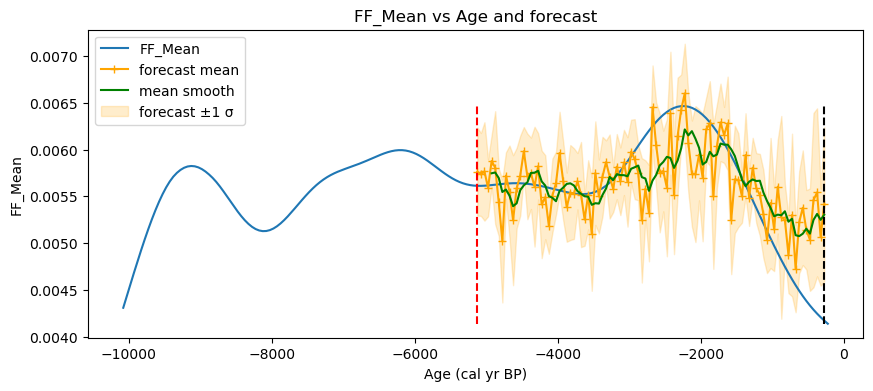

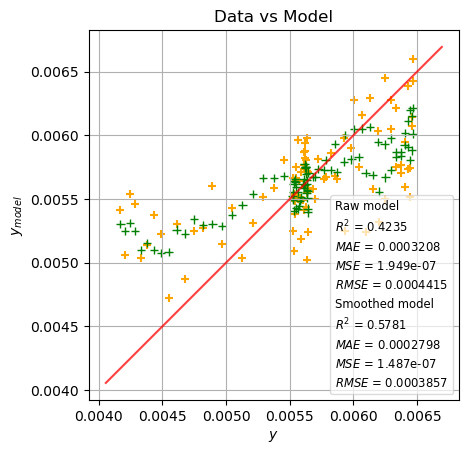

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "FF_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=feats=(df_all.columns[1:22].append(df_all.columns[25:-3]))#.append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)[:150]

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.5)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1    # forecast horizon (10 steps -> 500y)

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]


train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred_scaled = np.sqrt(np.exp(out[:, 1]))
std_pred = std_pred_scaled * scaler_y.scale_
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)
wdw=5
mean_smooth=rolling_mean_cumsum(mean_pred,window=wdw)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+",color='orange')
plt.plot(future_ages[wdw-1:], mean_smooth, label="mean smooth",color='g', marker="None")

fac_std=1
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.vlines(x=future_ages[0],ymin=np.min(y),ymax=np.max(y),
           color='r',linestyle='--',
           label='start pred.')
plt.vlines(x=future_ages[-1],ymin=np.min(y),ymax=np.max(y),
           color='k',linestyle='--',
           label='end pred.')

plt.title(f"{target_col} vs Age and forecast")


plt.show()

fig, ax = plt.subplots()
yy=df_all[df_all['Age'].isin(future_ages)][target_col]

# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=yy,y=mean_pred,
           marker='+',color='orange',label='model')
ax.scatter(x=yy[wdw-1:],y=mean_smooth,marker='+',
           color='g',linestyle='',
           label='smooth')


# ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
r2 = r2_score(yy, mean_pred)
mae = mean_absolute_error(yy,mean_pred)
mse = mean_squared_error(yy,mean_pred)
rmse = root_mean_squared_error(yy, mean_pred)


handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 10
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('Raw model' )
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
r2 = r2_score(yy[wdw-1:], mean_smooth)
mae = mean_absolute_error(yy[wdw-1:],mean_smooth)
mse = mean_squared_error(yy[wdw-1:],mean_smooth)
rmse = root_mean_squared_error(yy[wdw-1:], mean_smooth)
labels.append('Smoothed model' )
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)


epoch 01 train_loss=0.80075 val_loss=0.64451
epoch 02 train_loss=0.61249 val_loss=0.52889
epoch 03 train_loss=0.48898 val_loss=0.44676
epoch 04 train_loss=0.40791 val_loss=0.38167
epoch 05 train_loss=0.35825 val_loss=0.32433
epoch 06 train_loss=0.29550 val_loss=0.27175
epoch 07 train_loss=0.26318 val_loss=0.22425
epoch 08 train_loss=0.21743 val_loss=0.18152
epoch 09 train_loss=0.17145 val_loss=0.14146
epoch 10 train_loss=0.13164 val_loss=0.10335
forecast FF_Mean (next steps): [0.08346782 0.07111605 0.08216541 0.07027945 0.05520553 0.08946288
 0.06187995 0.05863957 0.07780582 0.07471879 0.07589741 0.08590342
 0.07519475 0.07142962 0.07795522 0.08176217 0.08735146 0.06987024
 0.06932167 0.05227869 0.08136264 0.07546156 0.08461077 0.09104082
 0.07954224 0.08680493 0.0814501  0.05993683 0.07585327 0.06975698
 0.07577221 0.06662513 0.07354901 0.05710277 0.07336321 0.07409535
 0.05449883 0.06659931 0.0618231  0.06246416 0.05612253 0.058016
 0.06979524 0.08390114 0.09065083 0.07804953 0.07752

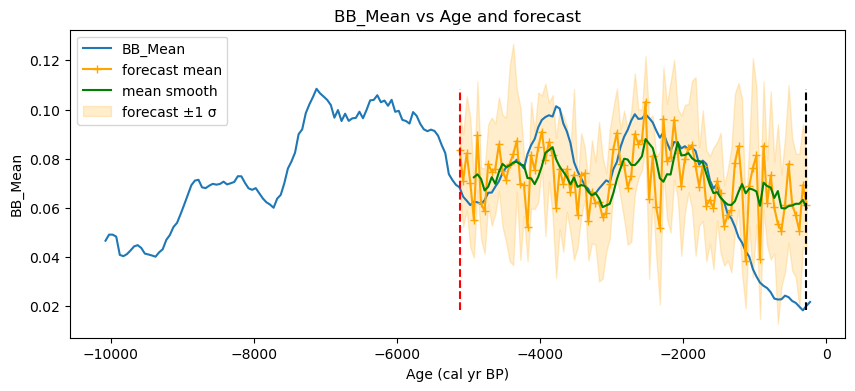

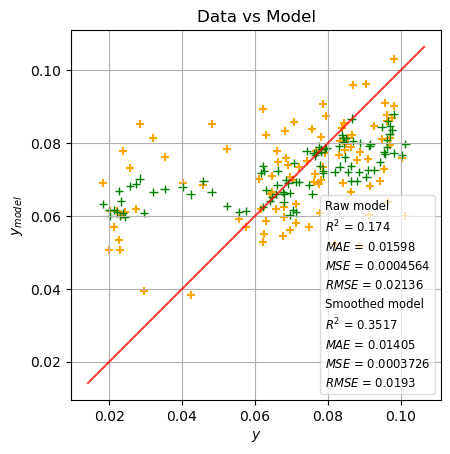

In [74]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "BB_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=feats=(df_all.columns[1:22].append(df_all.columns[25:-3]))#.append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.50)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1    # forecast horizon (10 steps -> 500y)

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]


train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred_scaled = np.sqrt(np.exp(out[:, 1]))
std_pred = std_pred_scaled * scaler_y.scale_
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)
wdw=5
mean_smooth=rolling_mean_cumsum(mean_pred,window=wdw)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+",color='orange')
plt.plot(future_ages[wdw-1:], mean_smooth, label="mean smooth",color='g', marker="None")

fac_std=1
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.vlines(x=future_ages[0],ymin=np.min(y),ymax=np.max(y),
           color='r',linestyle='--',
           label='start pred.')
plt.vlines(x=future_ages[-1],ymin=np.min(y),ymax=np.max(y),
           color='k',linestyle='--',
           label='end pred.')

plt.title(f"{target_col} vs Age and forecast")


plt.show()

fig, ax = plt.subplots()
yy=df_all[df_all['Age'].isin(future_ages)][target_col]

# ax.scatter(x=y,y=b+df_model,marker='+')
ax.scatter(x=yy,y=mean_pred,
           marker='+',color='orange',label='model')
ax.scatter(x=yy[wdw-1:],y=mean_smooth,marker='+',
           color='g',linestyle='',
           label='smooth')


# ax.scatter(x=y_test,y=y_pred,marker='+',color='purple',label='test')
ax.set_xlabel(r'$y$')
ax.set_ylabel(r'$y_{model}$')
ax.set_title('Data vs Model')
ax.legend()
ax.set_aspect('equal',adjustable='box')
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against eachother
ax.plot(lims, lims, 'r-', alpha=0.75, zorder=10)
ax.grid()
# Calculate and print R^2 score.
r2 = r2_score(yy, mean_pred)
mae = mean_absolute_error(yy,mean_pred)
mse = mean_squared_error(yy,mean_pred)
rmse = root_mean_squared_error(yy, mean_pred)


handles = [mpl_patches.Rectangle((0, 0), 1, 1, fc="white", ec="white", 
                                lw=0, alpha=0)] * 10
# create the corresponding number of labels (= the text you want to display)
labels = []#"R-squared: {r2}"
labels.append('Raw model' )
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
r2 = r2_score(yy[wdw-1:], mean_smooth)
mae = mean_absolute_error(yy[wdw-1:],mean_smooth)
mse = mean_squared_error(yy[wdw-1:],mean_smooth)
rmse = root_mean_squared_error(yy[wdw-1:], mean_smooth)
labels.append('Smoothed model' )
labels.append('$R^2$ = {0:.4g}'.format(r2) )
labels.append('$MAE$ = {0:.4g}'.format(mae) )
labels.append('$MSE$ = {0:.4g}'.format(mse) )
labels.append('$RMSE$ = {0:.4g}'.format(rmse) )
# create the legend, supressing the blank space of the empty line symbol and the
# padding between symbol and label by setting handlelenght and handletextpad
ax.legend(handles, labels, loc='best', fontsize='small', 
        fancybox=True, framealpha=0.7, 
        handlelength=0, handletextpad=0)


epoch 01 train_loss=1.31316 val_loss=0.92543
epoch 02 train_loss=0.84614 val_loss=0.66891
epoch 03 train_loss=0.72822 val_loss=0.51040
epoch 04 train_loss=0.49297 val_loss=0.41120
epoch 05 train_loss=0.39125 val_loss=0.34817
epoch 06 train_loss=0.35001 val_loss=0.30434
epoch 07 train_loss=0.29629 val_loss=0.26940
epoch 08 train_loss=0.27744 val_loss=0.23558
epoch 09 train_loss=0.23861 val_loss=0.20121
epoch 10 train_loss=0.21586 val_loss=0.16654
forecast FF_Mean (next steps): [0.08209284 0.0648762  0.09012012 0.09211152 0.08677827 0.07896782
 0.08672275 0.08053664 0.09134502 0.08582655 0.07100537 0.07355535
 0.08595066 0.08818354 0.08603536 0.0867489  0.08006027 0.06407994
 0.07699414 0.08410764 0.07925717 0.06344446 0.08172561 0.05503508
 0.05778383 0.07445552 0.06854618 0.07281353 0.05183705 0.08116052
 0.06617045 0.03942299 0.06234691 0.05452094 0.06950986 0.03616282
 0.03975467 0.03839587 0.04472858 0.04755174 0.05512377 0.05204406
 0.04829366 0.0536982  0.06408317 0.02451454 0.042

Text(0.5, 1.0, 'BB_Mean vs Age and forecast')

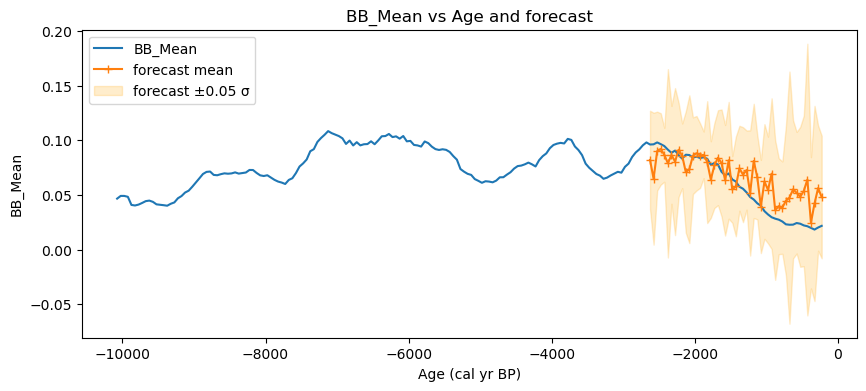

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "BB_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=feats=(df_all.columns[1:22])#.append(df_all.columns[25:-6])).append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.75)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1   # forecast horizon (10 steps -> 500y)

def make_sequences(X, Y, input_len, pred_len):
    seqs = []
    for i in range(len(X) - input_len - pred_len + 1):
        src = X[i : i + input_len]
        tgt = Y[i + input_len : i + input_len + pred_len]
        seqs.append((src, tgt))
    return seqs

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]

train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred = np.sqrt(np.exp(out[:, 1]))
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+")
fac_std=5E-2
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.title(f"{target_col} vs Age and forecast")

epoch 01 train_loss=1.12256 val_loss=0.89365
epoch 02 train_loss=0.89345 val_loss=0.70383
epoch 03 train_loss=0.72455 val_loss=0.57267
epoch 04 train_loss=0.57752 val_loss=0.47692
epoch 05 train_loss=0.47303 val_loss=0.40213
epoch 06 train_loss=0.42172 val_loss=0.34122
epoch 07 train_loss=0.34706 val_loss=0.28818
epoch 08 train_loss=0.30700 val_loss=0.24076
epoch 09 train_loss=0.25583 val_loss=0.19818
epoch 10 train_loss=0.19977 val_loss=0.15880
forecast FF_Mean (next steps): [0.62824565 0.635425   0.64570934 0.635691   0.6459392  0.6570353
 0.6489351  0.63193166 0.6342057  0.6236383  0.65705353 0.6500131
 0.62616026 0.6538003  0.62494993 0.63369536 0.652462   0.6654039
 0.64818084 0.65136766 0.6341976  0.6467391  0.6847848  0.6615939
 0.6617578  0.6429815  0.6447143  0.6587573  0.63678575 0.64766383
 0.6308429  0.6499346  0.6294364  0.6531647  0.630857   0.62977266
 0.6465727  0.63304573 0.63855827 0.6216619  0.6402549  0.62484074
 0.63321674 0.6572494  0.6408109  0.6540784  0.6473471

Text(0.5, 1.0, 'FS_Mean vs Age and forecast')

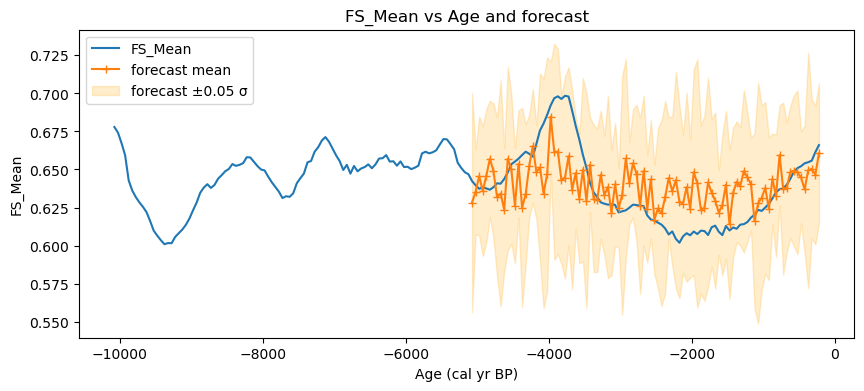

In [38]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "FS_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=feats=(df_all.columns[1:22])#.append(df_all.columns[25:-6])).append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.5)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1   # forecast horizon (10 steps -> 500y)

def make_sequences(X, Y, input_len, pred_len):
    seqs = []
    for i in range(len(X) - input_len - pred_len + 1):
        src = X[i : i + input_len]
        tgt = Y[i + input_len : i + input_len + pred_len]
        seqs.append((src, tgt))
    return seqs

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]

class TimeSeriesDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        src, tgt = self.seqs[idx]
        return torch.tensor(src, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)

train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)

# --- simple Informer-style encoder + probabilistic output ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class InformerProbModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, pred_len=10):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=input_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, pred_len * 2)  # mean + logvar
        self.pred_len = pred_len

    def forward(self, src):
        x = self.input_proj(src)
        x = self.pos_enc(x)
        memory = self.encoder(x)
        h = memory[:, -1, :]  # use last time step
        out = self.out(h)
        out = out.view(-1, self.pred_len, 2)
        return out

def gaussian_nll(pred, target):
    mean, logvar = pred[..., 0], pred[..., 1]
    var = torch.exp(logvar)
    return 0.5 * (logvar + (target.squeeze(-1) - mean) ** 2 / var).mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred = np.sqrt(np.exp(out[:, 1]))
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+")
fac_std=5E-2
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.title(f"{target_col} vs Age and forecast")

### base

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "FS_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=feats=(df_all.columns[1:22])#.append(df_all.columns[25:-6])).append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.75)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1   # forecast horizon (10 steps -> 500y)

def make_sequences(X, Y, input_len, pred_len):
    seqs = []
    for i in range(len(X) - input_len - pred_len + 1):
        src = X[i : i + input_len]
        tgt = Y[i + input_len : i + input_len + pred_len]
        seqs.append((src, tgt))
    return seqs

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]

class TimeSeriesDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        src, tgt = self.seqs[idx]
        return torch.tensor(src, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)

train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)

# --- simple Informer-style encoder + probabilistic output ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class InformerProbModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, pred_len=10):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=input_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, pred_len * 2)  # mean + logvar
        self.pred_len = pred_len

    def forward(self, src):
        x = self.input_proj(src)
        x = self.pos_enc(x)
        memory = self.encoder(x)
        h = memory[:, -1, :]  # use last time step
        out = self.out(h)
        out = out.view(-1, self.pred_len, 2)
        return out

def gaussian_nll(pred, target):
    mean, logvar = pred[..., 0], pred[..., 1]
    var = torch.exp(logvar)
    return 0.5 * (logvar + (target.squeeze(-1) - mean) ** 2 / var).mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred = np.sqrt(np.exp(out[:, 1]))
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+")
fac_std=5E-2
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.title(f"{target_col} vs Age and forecast")

## interactions

In [65]:
df=df_all
# Create interaction columns between features (excluding fire-related variables)
# Get all columns except Age and fire-related variables
base_cols = [col for col in df.columns if col not in ['Age', 'FF_Mean', 'FS_Mean', 'BB_Mean', 'FF_Mean_diff', 'FS_Mean_diff', 'BB_Mean_diff']]

# Create all pairwise interactions
for i in range(len(base_cols)):
    for j in range(i+1, len(base_cols)):
        col_name = f"{base_cols[i]}_{base_cols[j]}"
        df[col_name] = df[base_cols[i]] * df[base_cols[j]]

C:\Users\leoge\AppData\Local\Temp\ipykernel_11488\675020514.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[base_cols[i]] * df[base_cols[j]]
C:\Users\leoge\AppData\Local\Temp\ipykernel_11488\675020514.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col_name] = df[base_cols[i]] * df[base_cols[j]]
C:\Users\leoge\AppData\Local\Temp\ipykernel_11488\675020514.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perfor

In [79]:
df.columns[1:22].append(df.columns[25:46]).append(df.columns[50:])

Index(['Abies', 'Cupressaceae', 'Larix', 'Picea', 'Pinus', 'Alnus', 'Betula',
       'Populus', 'Quercus', 'Salix',
       ...
       'Poaceae_diff_Aquatics_diff', 'Poaceae_diff_TS_diff',
       'Poaceae_diff_PRECT_diff', 'Poaceae_diff_human_diff',
       'Aquatics_diff_TS_diff', 'Aquatics_diff_PRECT_diff',
       'Aquatics_diff_human_diff', 'TS_diff_PRECT_diff', 'TS_diff_human_diff',
       'PRECT_diff_human_diff'],
      dtype='object', length=902)

epoch 01 train_loss=1.04317 val_loss=0.56166
epoch 02 train_loss=0.48699 val_loss=0.38349
epoch 03 train_loss=0.34458 val_loss=0.28150
epoch 04 train_loss=0.26246 val_loss=0.20875
epoch 05 train_loss=0.18738 val_loss=0.15484
epoch 06 train_loss=0.14097 val_loss=0.11331
epoch 07 train_loss=0.10334 val_loss=0.07608
epoch 08 train_loss=0.08949 val_loss=0.03986
epoch 09 train_loss=0.03815 val_loss=0.00386
epoch 10 train_loss=-0.00861 val_loss=-0.03161
forecast FF_Mean (next steps): [0.6335225  0.64642316 0.6316325  0.6355139  0.62121063 0.61859775
 0.6347129  0.6148889  0.61934215 0.62827927 0.6138426  0.6299048
 0.62221754 0.6268635  0.6184737  0.62294936 0.6169656  0.6324672
 0.6280803  0.6313114  0.6206305  0.6433806  0.62584865 0.63608867
 0.63107216 0.6314973  0.61868674 0.61715966 0.6469476  0.63009155
 0.6215125  0.6354739  0.62780523 0.6341884  0.6186883  0.63027817
 0.6270499  0.645084   0.6426375  0.641035   0.64848226 0.6372911
 0.6565974  0.6399776  0.6436485  0.6512068  0.6515

Text(0.5, 1.0, 'FS_Mean vs Age and forecast')

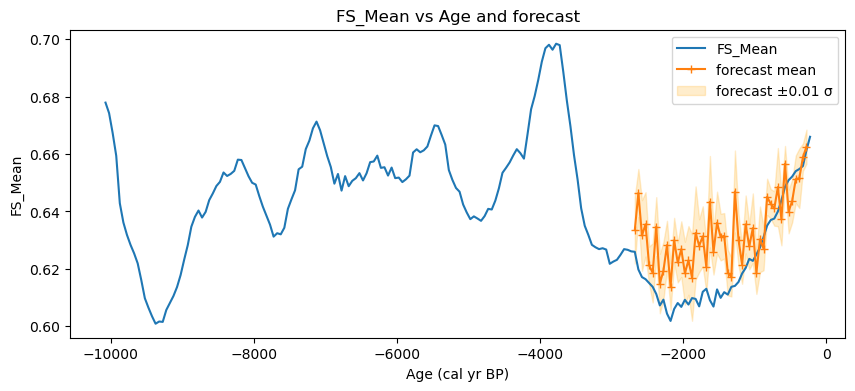

In [91]:
import torch
from torch.utils.data import Dataset, DataLoader

# --- prepare data (multivariate features + target) ---
target_col = "FS_Mean"
targets=["FF_Mean","BB_Mean","FS_Mean"]
feature_cols=  df.columns[1:22].append(df.columns[25:46]).append(df.columns[50:])

#=feats=(df_all.columns[1:22])#.append(df_all.columns[25:-6])).append(df_all.columns[-3:]).values
# feature_cols = [c for c in df_all.columns if c not in ["Age", targets]]

data = df_all[np.append(feature_cols,target_col)].dropna().reset_index(drop=True)

# scale inputs and target
scaler_X = StandardScaler().fit(data[feature_cols])
scaler_y = StandardScaler().fit(data[[target_col]])

X_scaled = scaler_X.transform(data[feature_cols])
y_scaled = scaler_y.transform(data[[target_col]])

# sequence dataset
input_len = floor(len(X_scaled)*0.75)  # 120 timesteps (50y each -> 6000y)
pred_len = len(X_scaled)-input_len-1   # forecast horizon (10 steps -> 500y)

def make_sequences(X, Y, input_len, pred_len):
    seqs = []
    for i in range(len(X) - input_len - pred_len + 1):
        src = X[i : i + input_len]
        tgt = Y[i + input_len : i + input_len + pred_len]
        seqs.append((src, tgt))
    return seqs

seqs = make_sequences(X_scaled, y_scaled, input_len, pred_len)

train_size = int(len(seqs) * 0.8)
train_seqs = seqs[:train_size]
val_seqs = seqs[train_size:]

class TimeSeriesDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        src, tgt = self.seqs[idx]
        return torch.tensor(src, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)

train_loader = DataLoader(TimeSeriesDataset(train_seqs), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(val_seqs), batch_size=32, shuffle=False)

# --- simple Informer-style encoder + probabilistic output ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, : x.size(1)]

class InformerProbModel(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, pred_len=10):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=input_len)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out = nn.Linear(d_model, pred_len * 2)  # mean + logvar
        self.pred_len = pred_len

    def forward(self, src):
        x = self.input_proj(src)
        x = self.pos_enc(x)
        memory = self.encoder(x)
        h = memory[:, -1, :]  # use last time step
        out = self.out(h)
        out = out.view(-1, self.pred_len, 2)
        return out

def gaussian_nll(pred, target):
    mean, logvar = pred[..., 0], pred[..., 1]
    var = torch.exp(logvar)
    return 0.5 * (logvar + (target.squeeze(-1) - mean) ** 2 / var).mean()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InformerProbModel(n_features=len(feature_cols), pred_len=pred_len).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# training loop
for epoch in range(10):
    model.train()
    train_loss = 0.0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        pred = model(src)
        loss = gaussian_nll(pred, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        train_loss += loss.item() * src.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            pred = model(src)
            val_loss += gaussian_nll(pred, tgt).item() * src.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"epoch {epoch+1:02d} train_loss={train_loss:.5f} val_loss={val_loss:.5f}")

# forecast on last available window
model.eval()
src = torch.tensor(X_scaled[-input_len:], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    out = model(src).cpu().numpy()[0]
mean_pred = scaler_y.inverse_transform(out[:, 0].reshape(-1, 1)).flatten()
std_pred = np.sqrt(np.exp(out[:, 1]))
print("forecast FF_Mean (next steps):", mean_pred)

## plot ##
age = df_all["Age"]
y = df_all[target_col]

last_age = age.iloc[input_len]
future_ages = np.arange(
    last_age + time_resolution,
    last_age + pred_len * time_resolution + 1,
    time_resolution,
)

plt.figure(figsize=(10, 4))
plt.plot(age, y, label=target_col)
plt.plot(future_ages, mean_pred, label="forecast mean", marker="+")
fac_std=1E-2
plt.fill_between(
    future_ages,
    mean_pred - fac_std * std_pred,
    mean_pred + fac_std * std_pred,
    alpha=0.2,
    label=f"forecast ±{fac_std} σ",color='orange'
)
plt.xlabel("Age (cal yr BP)")
plt.ylabel(target_col)
plt.legend()
plt.title(f"{target_col} vs Age and forecast")

# 2nd approach

In [52]:
from torch import nn
import math

def probsparse_attention(query_states, key_states, value_states, sampling_factor=5):
    """
    Compute the probsparse self-attention.
    Input shape: Batch x Time x Channel

    Note the additional `sampling_factor` input.
    """
    # get input sizes with logs
    L_K = key_states.size(1)
    L_Q = query_states.size(1)
    log_L_K = np.ceil(np.log1p(L_K)).astype("int").item()
    log_L_Q = np.ceil(np.log1p(L_Q)).astype("int").item()

    # calculate a subset of samples to slice from K and create Q_K_sample
    U_part = min(sampling_factor * L_Q * log_L_K, L_K)

    # create Q_K_sample (the q_i * k_j^T term in the sparsity measurement)
    index_sample = torch.randint(0, L_K, (U_part,))
    K_sample = key_states[:, index_sample, :]
    Q_K_sample = torch.bmm(query_states, K_sample.transpose(1, 2))

    # calculate the query sparsity measurement with Q_K_sample
    M = Q_K_sample.max(dim=-1)[0] - torch.div(Q_K_sample.sum(dim=-1), L_K)

    # calculate u to find the Top-u queries under the sparsity measurement
    u = min(sampling_factor * log_L_Q, L_Q)
    M_top = M.topk(u, sorted=False)[1]

    # calculate Q_reduce as query_states[:, M_top]
    dim_for_slice = torch.arange(query_states.size(0)).unsqueeze(-1)
    Q_reduce = query_states[dim_for_slice, M_top]  # size: c*log_L_Q x channel

    # and now, same as the canonical
    d_k = query_states.size(-1)
    attn_scores = torch.bmm(Q_reduce, key_states.transpose(-2, -1))  # Q_reduce x K^T
    attn_scores = attn_scores / math.sqrt(d_k)
    attn_probs = nn.functional.softmax(attn_scores, dim=-1)
    attn_output = torch.bmm(attn_probs, value_states)

    return attn_output, attn_scores

# <!-- Note that in the implementation,  Upart  contain  LQ  in the calculation for stability issues (see this disccusion for more information).

# We did it! Please be aware that this is only a partial implementation of the probsparse_attention, and the full implementation can be found in 🤗 Transformers.

# Distilling
# Because of the ProbSparse self-attention, the encoder’s feature map has some redundancy that can be removed. Therefore, the distilling operation is used to reduce the input size between encoder layers into its half slice, thus in theory removing this redundancy. In practice, Informer's "distilling" operation just adds 1D convolution layers with max pooling between each of the encoder layers. Let  Xn  be the output of the  n -th encoder layer, the distilling operation is then defined as:

# Xn+1=MaxPool(ELU(Conv1d(Xn)) 

# Let's see this in code: -->


# ConvLayer is a class with forward pass applying ELU and MaxPool1d
def informer_encoder_forward(x_input, num_encoder_layers=3, distil=True):
    # Initialize the convolution layers
    if distil:
        conv_layers = nn.ModuleList([ConvLayer() for _ in range(num_encoder_layers - 1)])
        conv_layers.append(None)
    else:
        conv_layers = [None] * num_encoder_layers
    
    # Apply conv_layer between each encoder_layer
    for encoder_layer, conv_layer in zip(encoder_layers, conv_layers):
        output = encoder_layer(x_input)
        if conv_layer is not None:
            output = conv_layer(loutput)
    
    return output

class TimeSeriesDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        src, tgt = self.seqs[idx]
        return torch.tensor(src, dtype=torch.float32), torch.tensor(tgt, dtype=torch.float32)
    
    